In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import numpy as np

In [61]:
# 1. Load Data
data = pd.read_csv('D:\KULIAHHH\clustercc\data\CCDATA.csv')  # Ganti dengan path dataset Anda
data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [62]:
# 2. Rename Kolom
data = data.rename(columns={
    'CUST_ID': 'ID_Pelanggan',
    'BALANCE': 'Saldo',
    'BALANCE_FREQUENCY': 'Frekuensi_Saldo',
    'PURCHASES': 'Pembelian',
    'ONEOFF_PURCHASES': 'Pembelian_Sekali',
    'INSTALLMENTS_PURCHASES': 'Pembelian_Cicilan',
    'CASH_ADVANCE': 'Uang_Muka',
    'PURCHASES_FREQUENCY': 'Frekuensi_Pembelian',
    'ONEOFF_PURCHASES_FREQUENCY': 'Frekuensi_Pembelian_Sekali',
    'PURCHASES_INSTALLMENTS_FREQUENCY': 'Frekuensi_Pembelian_Cicilan',
    'CASH_ADVANCE_FREQUENCY': 'Frekuensi_Uang_Muka',
    'CASH_ADVANCE_TRX': 'Transaksi_Uang_Muka',
    'PURCHASES_TRX': 'Transaksi_Pembelian',
    'CREDIT_LIMIT': 'Batas_Kredit',
    'PAYMENTS': 'Pembayaran',
    'MINIMUM_PAYMENTS': 'Pembayaran_Minimum',
    'PRC_FULL_PAYMENT': 'Pembayaran_Penuh',
    'TENURE': 'Tenur'
})

# Tampilkan beberapa baris data setelah rename untuk memastikan kolom telah berhasil diganti
print(data.head())

  ID_Pelanggan        Saldo  Frekuensi_Saldo  Pembelian  Pembelian_Sekali  \
0       C10001    40.900749         0.818182      95.40              0.00   
1       C10002  3202.467416         0.909091       0.00              0.00   
2       C10003  2495.148862         1.000000     773.17            773.17   
3       C10004  1666.670542         0.636364    1499.00           1499.00   
4       C10005   817.714335         1.000000      16.00             16.00   

   Pembelian_Cicilan    Uang_Muka  Frekuensi_Pembelian  \
0               95.4     0.000000             0.166667   
1                0.0  6442.945483             0.000000   
2                0.0     0.000000             1.000000   
3                0.0   205.788017             0.083333   
4                0.0     0.000000             0.083333   

   Frekuensi_Pembelian_Sekali  Frekuensi_Pembelian_Cicilan  \
0                    0.000000                     0.083333   
1                    0.000000                     0.000000   
2 

In [63]:
print("Data Shape :" ,data.shape)
data.info()

Data Shape : (8950, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Pelanggan                 8950 non-null   object 
 1   Saldo                        8950 non-null   float64
 2   Frekuensi_Saldo              8950 non-null   float64
 3   Pembelian                    8950 non-null   float64
 4   Pembelian_Sekali             8950 non-null   float64
 5   Pembelian_Cicilan            8950 non-null   float64
 6   Uang_Muka                    8950 non-null   float64
 7   Frekuensi_Pembelian          8950 non-null   float64
 8   Frekuensi_Pembelian_Sekali   8950 non-null   float64
 9   Frekuensi_Pembelian_Cicilan  8950 non-null   float64
 10  Frekuensi_Uang_Muka          8950 non-null   float64
 11  Transaksi_Uang_Muka          8950 non-null   int64  
 12  Transaksi_Pembelian          8950 non-null   int64  

In [64]:
# Memilih fitur yang relevan untuk klasifikasi
X = data[['Saldo', 'Frekuensi_Saldo', 'Pembelian', 'Pembelian_Sekali',
          'Pembelian_Cicilan', 'Uang_Muka', 'Frekuensi_Pembelian',
          'Frekuensi_Pembelian_Sekali', 'Frekuensi_Pembelian_Cicilan',
          'Frekuensi_Uang_Muka', 'Batas_Kredit', 'Pembayaran',
          'Pembayaran_Minimum', 'Pembayaran_Penuh', 'Tenur']]

In [65]:
# Hanya kolom numerik yang diisi
numerical_cols = data.select_dtypes(include=['number']).columns
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].median())

In [66]:
data['Target'] = (data['Pembayaran_Penuh'] == 1).astype(int)

print("Distribusi Target baru (Biner):")
print(data['Target'].value_counts())


Distribusi Target baru (Biner):
Target
0    8462
1     488
Name: count, dtype: int64


In [67]:
# Target (Prediksi Pembayaran Penuh atau Minimum)
X = data.drop(['ID_Pelanggan', 'Pembayaran_Penuh', 'Pembayaran_Minimum', 'Target'], axis=1)
y = data['Target']

print(data[['Pembayaran_Penuh', 'Pembayaran_Minimum']].describe())



       Pembayaran_Penuh  Pembayaran_Minimum
count       8950.000000         8950.000000
mean           0.153715          844.906767
std            0.292499         2332.792322
min            0.000000            0.019163
25%            0.000000          170.857654
50%            0.000000          312.343947
75%            0.142857          788.713501
max            1.000000        76406.207520


In [68]:
#  Standarisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
# Memeriksa distribusi kelas setelah pembagian
print(y_train.value_counts())



Target
0    5931
1     334
Name: count, dtype: int64


In [70]:
# Menangani Ketidakseimbangan Kelas dengan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [71]:
print("Distribusi Kelas Sesudah Resampling:")
print(X, y.value_counts())

Distribusi Kelas Sesudah Resampling:
            Saldo  Frekuensi_Saldo  Pembelian  Pembelian_Sekali  \
0       40.900749         0.818182      95.40              0.00   
1     3202.467416         0.909091       0.00              0.00   
2     2495.148862         1.000000     773.17            773.17   
3     1666.670542         0.636364    1499.00           1499.00   
4      817.714335         1.000000      16.00             16.00   
...           ...              ...        ...               ...   
8945    28.493517         1.000000     291.12              0.00   
8946    19.183215         1.000000     300.00              0.00   
8947    23.398673         0.833333     144.40              0.00   
8948    13.457564         0.833333       0.00              0.00   
8949   372.708075         0.666667    1093.25           1093.25   

      Pembelian_Cicilan    Uang_Muka  Frekuensi_Pembelian  \
0                 95.40     0.000000             0.166667   
1                  0.00  6442.945483

In [72]:
# 9. Model 1: Support Vector Machine (SVM) dengan class_weight='balanced'
svm_model = SVC(kernel='linear', class_weight='balanced')
svm_model.fit(X_train_smote, y_train_smote)
svm_pred = svm_model.predict(X_test)

print("\nEvaluasi Model SVM:")
print(classification_report(y_test, svm_pred, zero_division=1))
print("Akurasi:", accuracy_score(y_test, svm_pred))



Evaluasi Model SVM:
              precision    recall  f1-score   support

           0       1.00      0.73      0.84      2531
           1       0.18      0.98      0.31       154

    accuracy                           0.74      2685
   macro avg       0.59      0.85      0.57      2685
weighted avg       0.95      0.74      0.81      2685

Akurasi: 0.7437616387337058


In [73]:
# 10. Model 2: Decision Tree dengan class_weight='balanced'
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
dt_model.fit(X_train_smote, y_train_smote)
dt_pred = dt_model.predict(X_test)

print("\nEvaluasi Model Decision Tree:")
print(classification_report(y_test, dt_pred, zero_division=1))
print("Akurasi:", accuracy_score(y_test, dt_pred))


Evaluasi Model Decision Tree:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      2531
           1       0.17      0.88      0.29       154

    accuracy                           0.75      2685
   macro avg       0.58      0.81      0.57      2685
weighted avg       0.94      0.75      0.82      2685

Akurasi: 0.7519553072625699


In [74]:
# Model 2: Gaussian Mixture Model (GMM) - Model Utama
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)
data['GMM_Cluster'] = gmm.predict(X)

In [75]:
# Model 3: Decision Tree Classifier - Model Pembanding
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

In [76]:
# Model 4: KMeans (Segmentasi) - Model Pembanding
kmeans = KMeans(n_clusters=2, random_state=42)  # 2 cluster: Pembayaran Penuh (1) dan Pembayaran Minimum (0)
kmeans.fit(X)
data['KMeans_Cluster'] = kmeans.labels_

In [77]:
# Evaluating the models
# Evaluating SVM
print("SVM Classification Report:")
print(classification_report(y_test, svm_pred))
print("Confusion Matrix SVM:")
print(confusion_matrix(y_test, svm_pred))

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.73      0.84      2531
           1       0.18      0.98      0.31       154

    accuracy                           0.74      2685
   macro avg       0.59      0.85      0.57      2685
weighted avg       0.95      0.74      0.81      2685

Confusion Matrix SVM:
[[1846  685]
 [   3  151]]


In [87]:
# 1. Mapping GMM Cluster ke Target
cluster_map = {}
for cluster in np.unique(gmm.predict(X_train)):
    cluster_labels = y_train[gmm.predict(X_train) == cluster]
    # Ambil label mayoritas dari tiap cluster
    majority_label = cluster_labels.mode()[0]
    cluster_map[cluster] = majority_label

# 2. Prediksi dan Mapping Cluster GMM untuk X_test
gmm_cluster_pred = gmm.predict(X_test)
gmm_pred = np.array([cluster_map[cluster] for cluster in gmm_cluster_pred])

# 3. Evaluasi Hasil
print("\nGMM Classification Report:")
print(classification_report(y_test, gmm_pred, zero_division=1))
print("Confusion Matrix GMM:")
print(confusion_matrix(y_test, gmm_pred))




GMM Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2531
           1       1.00      0.00      0.00       154

    accuracy                           0.94      2685
   macro avg       0.97      0.50      0.49      2685
weighted avg       0.95      0.94      0.91      2685

Confusion Matrix GMM:
[[2531    0]
 [ 154    0]]


c:\Users\NITRO-5\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
c:\Users\NITRO-5\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
c:\Users\NITRO-5\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
c:\Users\NITRO-5\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


In [79]:
# Evaluating Decision Tree
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred))
print("Confusion Matrix Decision Tree:")
print(confusion_matrix(y_test, dt_pred))


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      2531
           1       0.29      0.31      0.30       154

    accuracy                           0.92      2685
   macro avg       0.62      0.63      0.63      2685
weighted avg       0.92      0.92      0.92      2685

Confusion Matrix Decision Tree:
[[2416  115]
 [ 107   47]]


In [89]:
# 1. Mapping KMeans Cluster ke Target
kmeans_cluster_map = {}
for cluster in np.unique(kmeans.predict(X_train)):
    cluster_labels = y_train[kmeans.predict(X_train) == cluster]
    # Ambil label mayoritas dari tiap cluster
    majority_label = cluster_labels.mode()[0]
    kmeans_cluster_map[cluster] = majority_label

# 2. Prediksi dan Mapping Cluster KMeans untuk X_test
kmeans_cluster_pred = kmeans.predict(X_test)
kmeans_pred = np.array([kmeans_cluster_map[cluster] for cluster in kmeans_cluster_pred])

# 3. Evaluasi Hasil
print("\nKMeans Classification Report:")
print(classification_report(y_test, kmeans_pred, zero_division=1))
print("Confusion Matrix KMeans:")
print(confusion_matrix(y_test, kmeans_pred))



KMeans Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2531
           1       1.00      0.00      0.00       154

    accuracy                           0.94      2685
   macro avg       0.97      0.50      0.49      2685
weighted avg       0.95      0.94      0.91      2685

Confusion Matrix KMeans:
[[2531    0]
 [ 154    0]]


c:\Users\NITRO-5\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\NITRO-5\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\NITRO-5\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [81]:
# Comparing Performance Metrics: Accuracy of SVM vs Decision Tree vs GMM vs KMeans
svm_accuracy = accuracy_score(y_test, svm_pred)
gmm_accuracy = accuracy_score(y_test, gmm_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
kmeans_accuracy = accuracy_score(y_test, kmeans_pred)

In [82]:
print(f"\nSVM Accuracy: {svm_accuracy:.4f}")
print(f"GMM Accuracy: {gmm_accuracy:.4f}")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"KMeans Accuracy: {kmeans_accuracy:.4f}")
print(f"KMeans Accuracy: {kmeans_accuracy:.4f}")


SVM Accuracy: 0.7438
GMM Accuracy: 0.9426
Decision Tree Accuracy: 0.9173
KMeans Accuracy: 0.9426
KMeans Accuracy: 0.9426


In [83]:
# Visualize Cluster Distribution
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'KMeans Cluster Distribution')

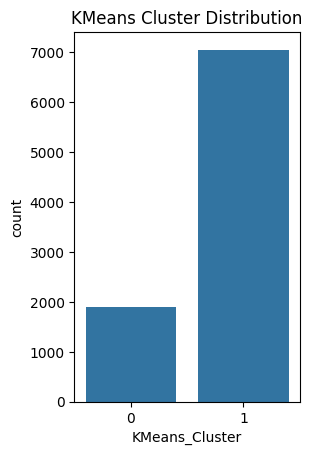

In [84]:
# Plot KMeans clusters
plt.subplot(1, 2, 1)
sns.countplot(x='KMeans_Cluster', data=data)
plt.title('KMeans Cluster Distribution')


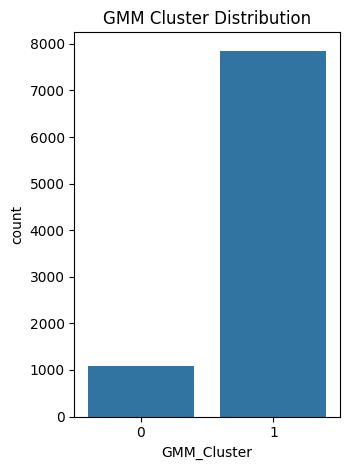

In [85]:
# Plot GMM clusters
plt.subplot(1, 2, 2)
sns.countplot(x='GMM_Cluster', data=data)
plt.title('GMM Cluster Distribution')

plt.tight_layout()
plt.show()